# Multistep amperometry — fixed-force, variable length (2026-05-06 14:54)

Pairs the scope length-sensor log with the potentiostat amperometry trace.
Time is on the shared X axis along the bottom.

- Scope: `scope_log_20260506_145429_forcefixed_length_variable_aqeuous_Test_10xgain.csv` (live signal on **CH1** at 10× gain — **CH2 is unused / zero**)
- Potentiostat: `data_from_potentiostat/05.06.25-neg40C-pyrrole-fixed-force-aqueous.csv` (`MultiStep Amperometry: i vs t`)

Length conversion: **length (mm) = −4.13 × scope V**.
Strain reference length **L₀ = 3.0 mm**.
Strain (%) = (length − L₀) / L₀ × 100.

In [21]:
# Load both files and align them on a common 'experiment time' axis (t_exp).
# t_exp = 0 when the potentiostat measurement starts.

import os
import io
import csv
import numpy as np
import pandas as pd
from datetime import datetime

SCOPE_CSV = 'scope_log_20260506_145429_forcefixed_length_variable_aqeuous_Test_10xgain.csv'
POTEN_CSV = 'data_from_potentiostat/05.06.25-neg40C-pyrrole-fixed-force-aqueous.csv'

# Offset override. None = use metadata. Positive = scope started this many
# seconds before the potentiostat measurement.
OFFSET_OVERRIDE_S = 33


# ---- 1. Potentiostat (UTF-16, MultiStep Amperometry: t,i columns) ----
with open(POTEN_CSV, 'rb') as f:
    text = f.read().decode('utf-16').replace('\ufeff', '')
lines = text.splitlines()
poten_start_str = lines[4].split(',')[1].strip()
poten_start = datetime.strptime(poten_start_str, '%Y-%m-%d %H:%M:%S')
data_rows = list(csv.reader(io.StringIO('\n'.join(lines[6:]))))
data_rows = [r for r in data_rows if len(r) >= 2 and r[0]]
poten = pd.DataFrame(data_rows, columns=['t_s', 'i_uA']).astype(float)
poten_total_s = float(poten['t_s'].max())


# ---- 2. Scope log + time alignment ----
scope = pd.read_csv(SCOPE_CSV)
scope_start = (datetime.fromisoformat(scope['timestamp'].iloc[0])
               - pd.Timedelta(seconds=float(scope['elapsed_s'].iloc[0])))
metadata_offset_s = (poten_start - scope_start).total_seconds()
offset_s = OFFSET_OVERRIDE_S if OFFSET_OVERRIDE_S is not None else metadata_offset_s

print(f'Scope start:        {scope_start}')
print(f'Potentiostat start: {poten_start}')
print(f'Offset from metadata: {metadata_offset_s:.2f} s')
if OFFSET_OVERRIDE_S is not None:
    print(f'Using manual override:  {offset_s:.2f} s')
print(f'Potentiostat duration: {poten_total_s:.1f} s')

scope['t_exp'] = scope['elapsed_s'] - offset_s
scope_clean = scope[(scope['t_exp'] >= 0) & (scope['t_exp'] <= poten_total_s)].copy()
scope_clean = scope_clean.sort_values('t_exp').reset_index(drop=True)
print(f'Scope rows in experiment window: {len(scope_clean)} / {len(scope)}')
scope_clean.head()

Scope start:        2026-05-06 14:54:29.484098
Potentiostat start: 2026-05-06 14:56:35
Offset from metadata: 125.52 s
Using manual override:  33.00 s
Potentiostat duration: 1600.0 s
Scope rows in experiment window: 6303 / 6486


,elapsed_s,timestamp,ch1_MEAN_V,ch2_MEAN_V,t_exp
0,33.002,2026-05-06T14:55:02.485717,-0.752,0.0,0.002
1,33.253,2026-05-06T14:55:02.737480,-0.752,0.0,0.253
2,33.507,2026-05-06T14:55:02.991498,-0.751,0.0,0.507
3,33.762,2026-05-06T14:55:03.245906,-0.751,0.0,0.762
4,34.016,2026-05-06T14:55:03.500256,-0.752,0.0,1.016


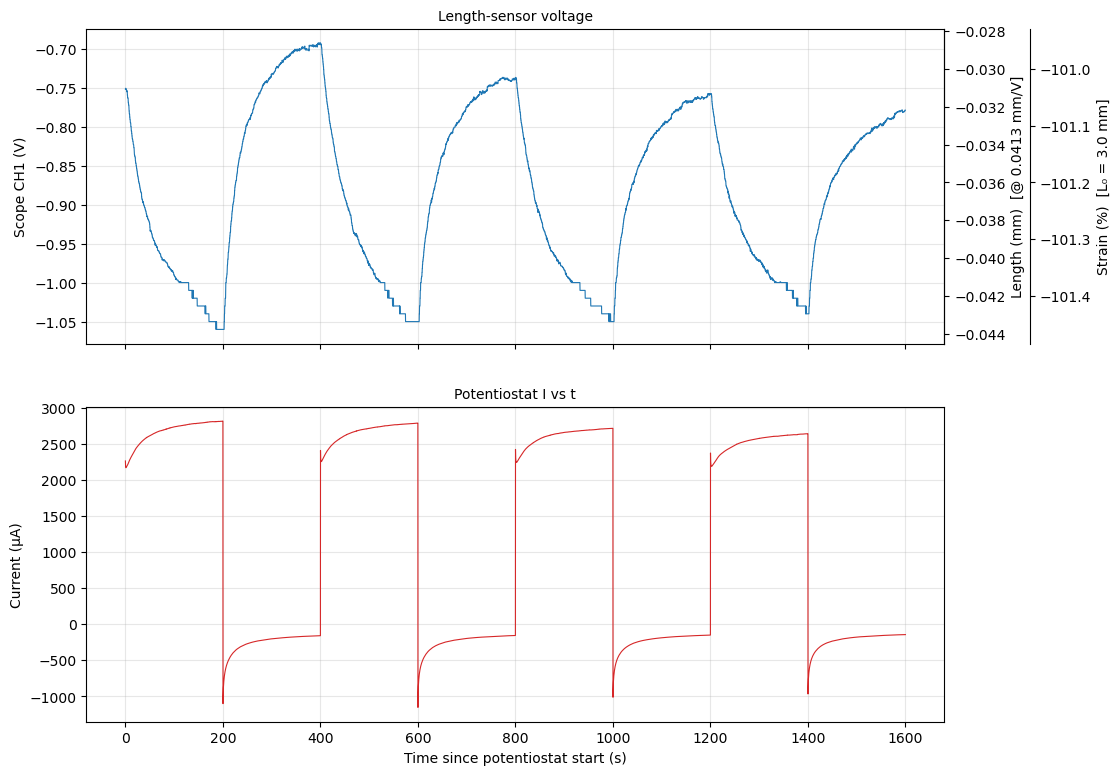

In [22]:
# Stacked plot, shared X-axis (time, seconds since potentiostat start).
# Top:    scope CH1 voltage, with extra Y axes for length (mm) and strain (%).
# Bottom: potentiostat current (µA).

import matplotlib.pyplot as plt

# --- Length / strain calibration ---
MM_PER_V = 0.0413          # length (mm) = MM_PER_V * scope V
L0_MM = 3.0               # reference length for strain (set to scope-derived
                          # starting length if you want strain to start at 0)

def v_to_mm(v):
    return v * MM_PER_V
def mm_to_v(mm):
    return mm / MM_PER_V
def v_to_strain_pct(v):
    return (v * MM_PER_V - L0_MM) / L0_MM * 100.0
def strain_pct_to_v(s):
    return (s * L0_MM / 100.0 + L0_MM) / MM_PER_V

fig, (ax_v, ax_i) = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

# --- Top: time on X, scope CH1 voltage on Y ---
ax_v.plot(scope_clean['t_exp'], scope_clean['ch1_MEAN_V'], color='#1f77b4', lw=0.8)
ax_v.set_ylabel('Scope CH1 (V)')
ax_v.set_title('Length-sensor voltage', fontsize=10)
ax_v.grid(True, alpha=0.3)

# Secondary Y axes (right): length (mm), then strain (%) offset further right
ax_v_mm = ax_v.secondary_yaxis('right', functions=(v_to_mm, mm_to_v))
ax_v_mm.set_ylabel(f'Length (mm)  [@ {MM_PER_V} mm/V]')

ax_v_strain = ax_v.secondary_yaxis(1.10, functions=(v_to_strain_pct, strain_pct_to_v))
ax_v_strain.set_ylabel(f'Strain (%)  [L₀ = {L0_MM} mm]')

# --- Bottom: time on X, potentiostat current on Y ---
ax_i.plot(poten['t_s'], poten['i_uA'], color='#d62728', lw=0.8)
ax_i.set_xlabel('Time since potentiostat start (s)')
ax_i.set_ylabel('Current (µA)')
ax_i.set_title('Potentiostat I vs t', fontsize=10)
ax_i.grid(True, alpha=0.3)

fig.subplots_adjust(right=0.84)
plt.show()